In [1]:
# =========================================
# 1. UPLOAD & EXTRACT ZIP
# =========================================
from google.colab import files
uploaded = files.upload()   # upload archive.zip

import zipfile, os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Folders:", os.listdir('/content/data'))

# UPDATE IF NEEDED
dataset_path = "/content/data/rice_leaf_diseases"

Saving archive (11).zip to archive (11).zip
Folders: ['rice_leaf_diseases']


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Total Images: 120
Train+Val: 102 Test: 18

CROSS VALIDATION START

--- Fold 1 ---
Fold Accuracy: 0.8095

--- Fold 2 ---
Fold Accuracy: 0.5238

--- Fold 3 ---
Fold Accuracy: 0.8000

--- Fold 4 ---
Fold Accuracy: 0.8500

--- Fold 5 ---
Fold Accuracy: 0.7500

CROSS VALIDATION RESULT
Fold Accuracies: [0.8095238208770752, 0.523809552192688, 0.800000011920929, 0.8500000238418579, 0.75]
Average CV Accuracy: 0.74666668176651

FINAL MODEL TRAINING ON FULL DATA
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.3627 - loss: 1.2129
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.4510 - loss: 1.0987
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.5490 - loss: 0.9374
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.6471 - loss: 0.8104
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.6667 - loss: 0.7900
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - a

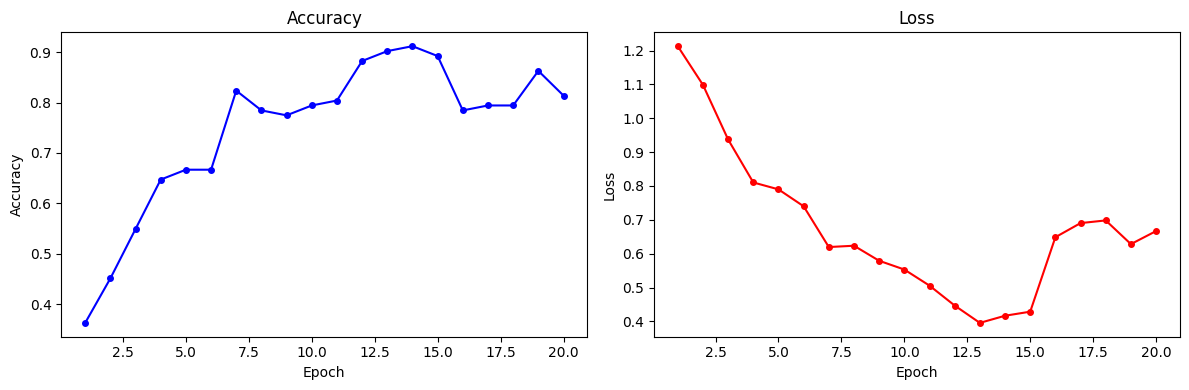


FINAL TEST EVALUATION
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 0.8333 - loss: 0.5060
FINAL TEST ACCURACY: 0.8333333134651184
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step


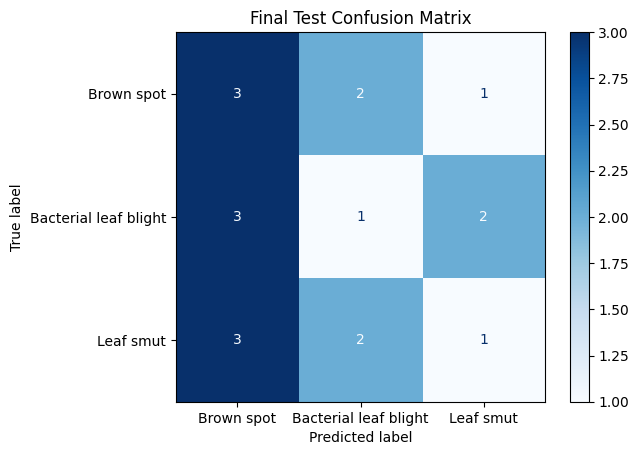


Classification Report:

              precision    recall  f1-score   support

           0       0.33      0.50      0.40         6
           1       0.20      0.17      0.18         6
           2       0.25      0.17      0.20         6

    accuracy                           0.28        18
   macro avg       0.26      0.28      0.26        18
weighted avg       0.26      0.28      0.26        18


OVERFITTING CHECK
Train Accuracy: 0.8137
Test Accuracy : 0.8333
Gap           : 0.0196
Good Generalization


In [9]:

# 1. IMPORTS

import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

print("GPU:", tf.config.list_physical_devices('GPU'))


# 2. LOAD DATA

dataset_path = "/content/data/rice_leaf_diseases"

classes = {
    "Brown spot": 0,
    "Bacterial leaf blight": 1,
    "Leaf smut": 2
}

IMG_SIZE = 224
data, labels = [], []

for class_name, label in classes.items():
    folder = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(label)

X = np.array(data, dtype="float32")
y = np.array(labels)

print("\nTotal Images:", len(X))


# 3. FINAL TEST SPLIT (LOCKED)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

print("Train+Val:", len(X_train_full), "Test:", len(X_test))


# 4. K-FOLD CROSS VALIDATION

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []

print("\nCROSS VALIDATION START")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):

    print(f"\n--- Fold {fold+1} ---")

    X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
    y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        zoom_range=0.15,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow(X_train, y_train, batch_size=16)
    val_gen = val_datagen.flow(X_val, y_val, batch_size=16)

    # MODEL
    base_model = EfficientNetB0(weights='imagenet', include_top=False,
                               input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_gen, epochs=12, validation_data=val_gen, verbose=0)

    # FINE-TUNE
    base_model.trainable = True
    for layer in base_model.layers[:-15]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-6),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_gen, epochs=4, validation_data=val_gen, verbose=0)

    loss, acc = model.evaluate(val_gen, verbose=0)
    print(f"Fold Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nCROSS VALIDATION RESULT")
print("Fold Accuracies:", cv_accuracies)
print("Average CV Accuracy:", np.mean(cv_accuracies))

# 5. FINAL MODEL TRAINING

print("\nFINAL MODEL TRAINING ON FULL DATA")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

train_gen = train_datagen.flow(X_train_full, y_train_full, batch_size=16)

base_model = EfficientNetB0(weights='imagenet', include_top=False,
                           input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation='softmax')(x)

final_model = models.Model(inputs=base_model.input, outputs=output)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = final_model.fit(train_gen, epochs=15, verbose=1)

# FINE-TUNE
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = final_model.fit(train_gen, epochs=5, verbose=1)
train_acc  = history.history['accuracy'] + history_fine.history['accuracy']
train_loss = history.history['loss']     + history_fine.history['loss']
epochs     = range(1, len(train_acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'b-o', markersize=4)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'r-o', markersize=4)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

# 6. FINAL TEST EVALUATION

print("\nFINAL TEST EVALUATION")

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow(
    X_test, y_test, batch_size=16
)

loss, acc = final_model.evaluate(test_gen)
print("FINAL TEST ACCURACY:", acc)


# 7. CONFUSION MATRIX

pred_probs = final_model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=list(classes.keys()))
disp.plot(cmap='Blues')
plt.title("Final Test Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# 8. OVERFITTING CHECK

train_acc = history.history['accuracy'] + history_fine.history['accuracy']
final_train_acc = train_acc[-1]

gap = abs(final_train_acc - acc)

print("\nOVERFITTING CHECK")
print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Test Accuracy : {acc:.4f}")
print(f"Gap           : {gap:.4f}")

if gap > 0.15:
    print("Overfitting")
else:
    print("Good Generalization")